In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**# -------------------- DATA CLEANING --------------------**#


In [2]:

df = pd.read_csv("crime.csv")
print(df.head())

          TYPE  YEAR  MONTH  DAY  HOUR  MINUTE     HUNDRED_BLOCK  \
0  Other Theft  2003      5   12  16.0    15.0  9XX TERMINAL AVE   
1  Other Theft  2003      5    7  15.0    20.0  9XX TERMINAL AVE   
2  Other Theft  2003      4   23  16.0    40.0  9XX TERMINAL AVE   
3  Other Theft  2003      4   20  11.0    15.0  9XX TERMINAL AVE   
4  Other Theft  2003      4   12  17.0    45.0  9XX TERMINAL AVE   

  NEIGHBOURHOOD         X           Y   Latitude   Longitude  
0    Strathcona  493906.5  5457452.47  49.269802 -123.083763  
1    Strathcona  493906.5  5457452.47  49.269802 -123.083763  
2    Strathcona  493906.5  5457452.47  49.269802 -123.083763  
3    Strathcona  493906.5  5457452.47  49.269802 -123.083763  
4    Strathcona  493906.5  5457452.47  49.269802 -123.083763  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 530652 entries, 0 to 530651
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           530652 non-null  str    
 1   YEAR           530652 non-null  int64  
 2   MONTH          530652 non-null  int64  
 3   DAY            530652 non-null  int64  
 4   HOUR           476290 non-null  float64
 5   MINUTE         476290 non-null  float64
 6   HUNDRED_BLOCK  530639 non-null  str    
 7   NEIGHBOURHOOD  474028 non-null  str    
 8   X              530652 non-null  float64
 9   Y              530652 non-null  float64
 10  Latitude       530652 non-null  float64
 11  Longitude      530652 non-null  float64
dtypes: float64(6), int64(3), str(3)
memory usage: 48.6 MB


**# Handle missing values**


In [4]:
df['HOUR'] = df['HOUR'].fillna(df['HOUR'].median())
df['MINUTE'] = df['MINUTE'].fillna(df['MINUTE'].median())
df['NEIGHBOURHOOD'] = df['NEIGHBOURHOOD'].fillna("Unknown")
df['HUNDRED_BLOCK'] = df['HUNDRED_BLOCK'].fillna("Unknown")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 530652 entries, 0 to 530651
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           530652 non-null  str    
 1   YEAR           530652 non-null  int64  
 2   MONTH          530652 non-null  int64  
 3   DAY            530652 non-null  int64  
 4   HOUR           530652 non-null  float64
 5   MINUTE         530652 non-null  float64
 6   HUNDRED_BLOCK  530652 non-null  str    
 7   NEIGHBOURHOOD  530652 non-null  str    
 8   X              530652 non-null  float64
 9   Y              530652 non-null  float64
 10  Latitude       530652 non-null  float64
 11  Longitude      530652 non-null  float64
dtypes: float64(6), int64(3), str(3)
memory usage: 48.6 MB


# Convert datatypes

In [5]:
df['HOUR'] = df['HOUR'].round().astype(int)
df['MINUTE'] = df['MINUTE'].round().astype(int)

In [6]:
df['DATETIME'] = pd.to_datetime(df[['YEAR','MONTH','DAY','HOUR','MINUTE']])
sns.set_style("whitegrid")


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 530652 entries, 0 to 530651
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           530652 non-null  str           
 1   YEAR           530652 non-null  int64         
 2   MONTH          530652 non-null  int64         
 3   DAY            530652 non-null  int64         
 4   HOUR           530652 non-null  int64         
 5   MINUTE         530652 non-null  int64         
 6   HUNDRED_BLOCK  530652 non-null  str           
 7   NEIGHBOURHOOD  530652 non-null  str           
 8   X              530652 non-null  float64       
 9   Y              530652 non-null  float64       
 10  Latitude       530652 non-null  float64       
 11  Longitude      530652 non-null  float64       
 12  DATETIME       530652 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(5), str(3)
memory usage: 52.6 MB


# -------------------- EDA --------------------

Crimes per Year

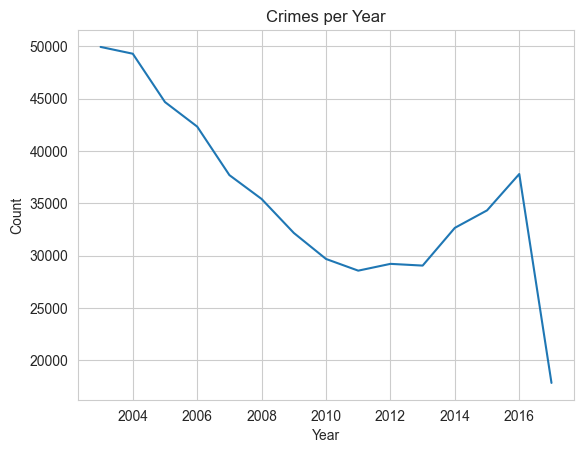

In [8]:
plt.figure()
df['YEAR'].value_counts().sort_index().plot(kind='line')
plt.title("Crimes per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


Crimes per Month

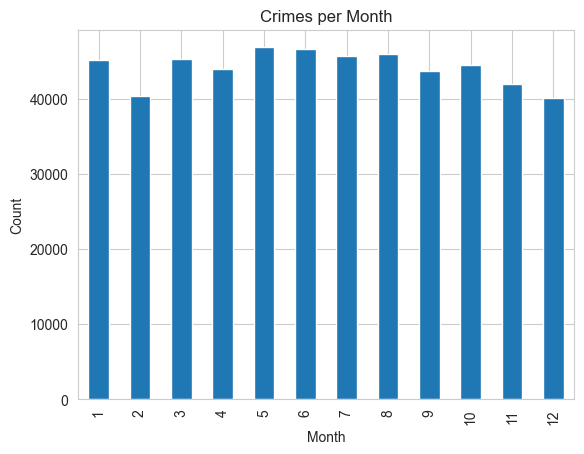

In [9]:
plt.figure()
df['MONTH'].value_counts().sort_index().plot(kind='bar')
plt.title("Crimes per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

Crimes by Type

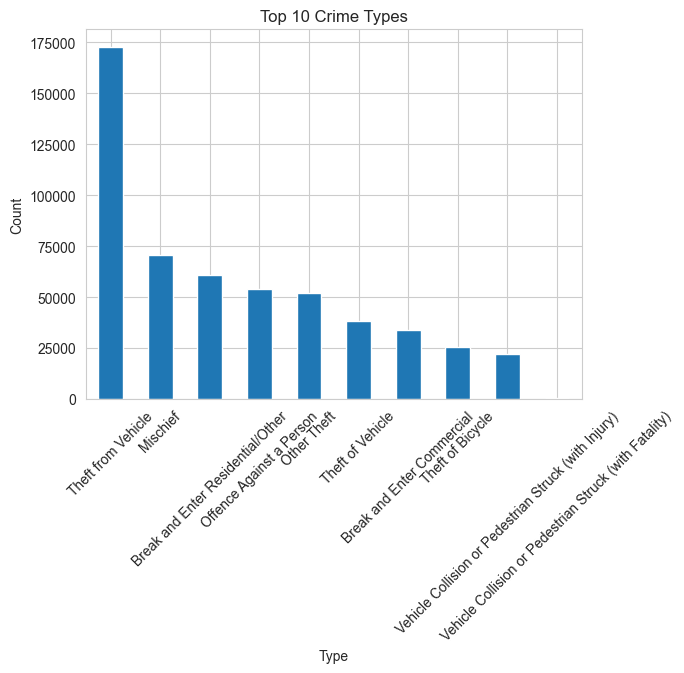

In [10]:
plt.figure()
df['TYPE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Crimes by Hour

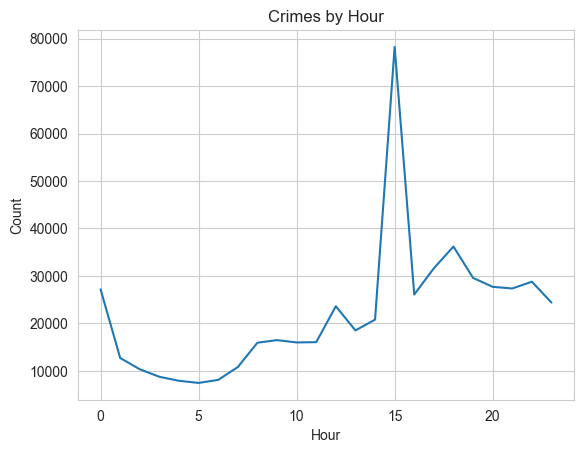

In [11]:
plt.figure()
df['HOUR'].value_counts().sort_index().plot(kind='line')
plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

Crimes by Neighbourhood (Top 10)

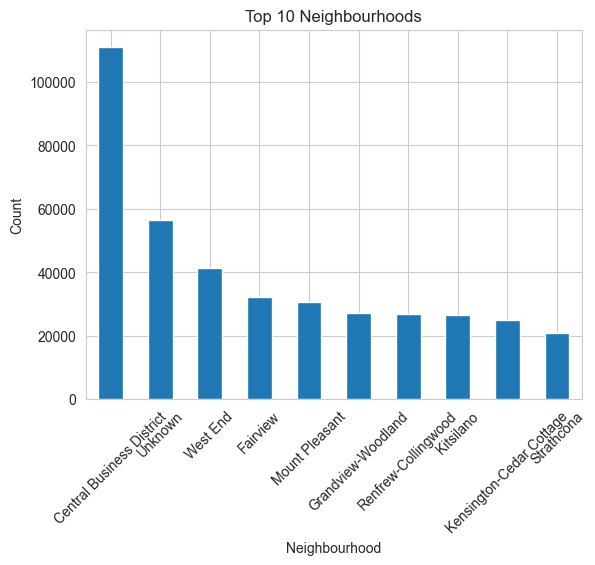

In [12]:
plt.figure()
df['NEIGHBOURHOOD'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Heatmap (Month vs Hour)

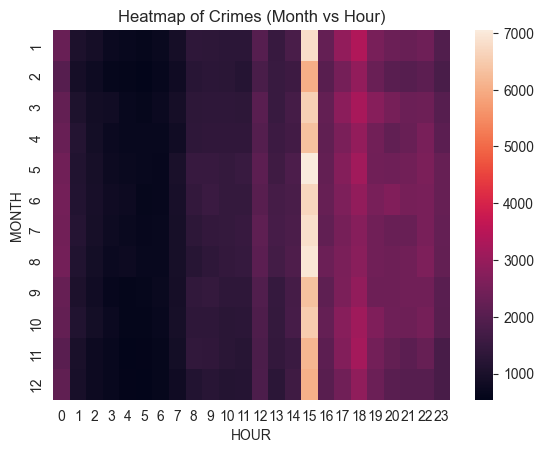

In [13]:
pivot = df.pivot_table(index='MONTH', columns='HOUR', values='TYPE', aggfunc='count')
plt.figure()
sns.heatmap(pivot)
plt.title("Heatmap of Crimes (Month vs Hour)")
plt.show()

Distribution of Crimes per Day

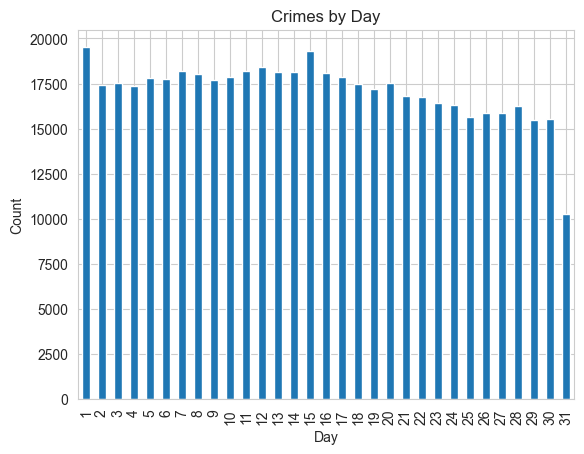

In [14]:
plt.figure()
df['DAY'].value_counts().sort_index().plot(kind='bar')
plt.title("Crimes by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

Select numerical columns

In [15]:
num_cols = ['HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY']

Boxplots before removing outliers

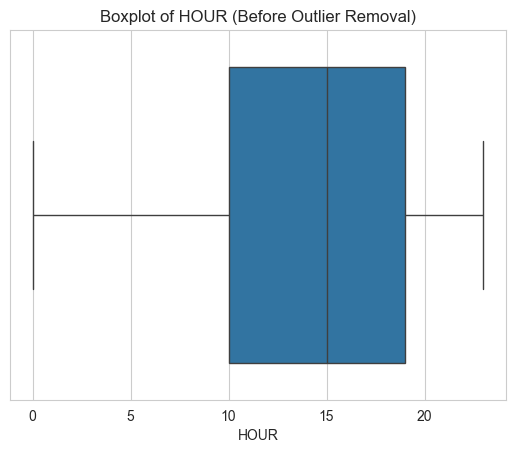

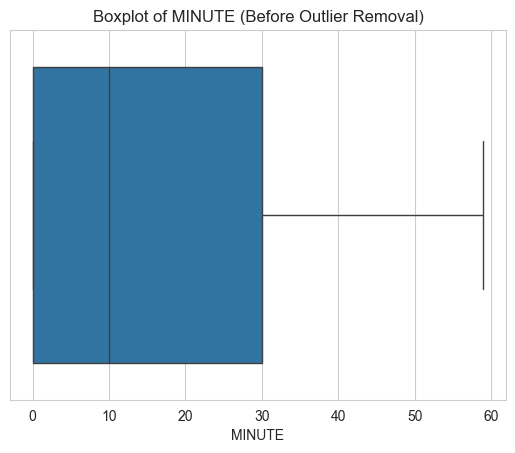

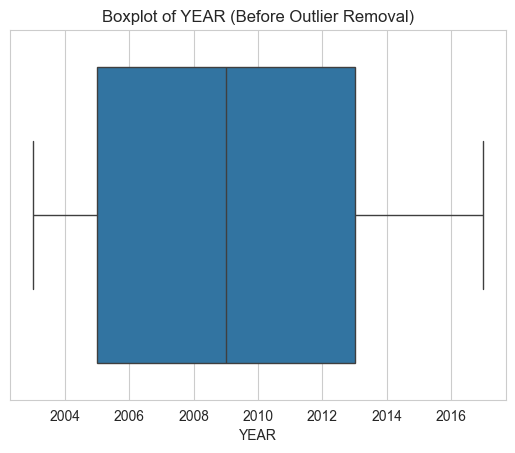

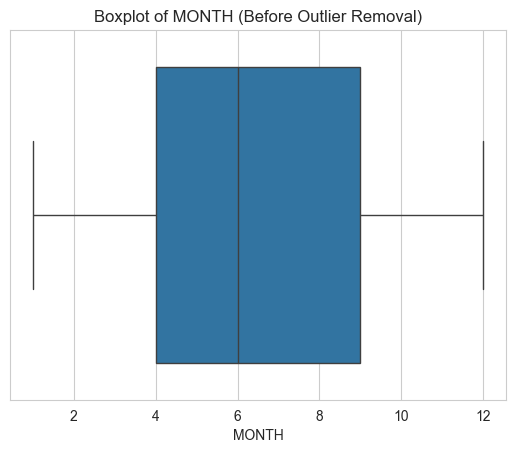

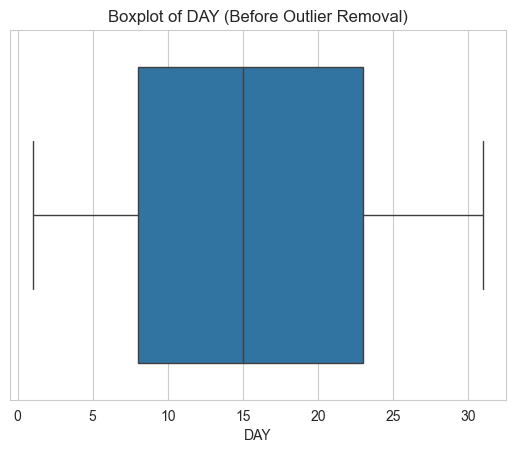

In [16]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Before Outlier Removal)')
    plt.show()

In [17]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df_clean = df.loc[~outlier_mask].copy()

print(f"Original rows: {len(df):,}")
print(f"Rows after outlier removal: {len(df_clean):,}")

Original rows: 530,652
Rows after outlier removal: 530,652


# -------------------- T-TEST --------------------

 Compare crime counts between two months (Jan vs Feb)

In [18]:
jan = df_clean[df_clean['MONTH'] == 1]['HOUR']
feb = df_clean[df_clean['MONTH'] == 2]['HOUR']

t_stat, p_val = stats.ttest_ind(jan, feb, nan_policy='omit')

print("T-Test:")
print("T-Statistic:", t_stat)
print("P-Value:", p_val)


T-Test:
T-Statistic: 0.1974587058128197
P-Value: 0.8434690617815569


# -------------------- Z-TEST --------------------
# Example: Compare sample mean (HOUR) with population mean

In [19]:
sample_size = min(1000, len(df_clean))
sample = df_clean['HOUR'].sample(sample_size, random_state=42)
pop_mean = df_clean['HOUR'].mean()
pop_std = df_clean['HOUR'].std()

z_stat = (sample.mean() - pop_mean) / (pop_std / np.sqrt(len(sample)))

p_val_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("\nZ-Test:")
print("Z-Statistic:", z_stat)
print("P-Value:", p_val_z)



Z-Test:
Z-Statistic: 0.44169300966914843
P-Value: 0.6587113687897881


# -------------------- CHI-SQUARE TEST --------------------

# Example: Relationship between TYPE and MONTH

In [20]:
contingency_table = pd.crosstab(df_clean['TYPE'], df_clean['MONTH'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-Square Test:")
print("Chi2 Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)


Chi-Square Test:
Chi2 Statistic: 6322.408153259659
P-Value: 0.0
Degrees of Freedom: 110
